# Analysis of Forest Density Across ∆Tb Clusters

This code supports Section 3.3 (Clustering of ∆Tb climatology) by analyzing the distribution of mean forest density across clusters.

A 29-year time series of 300 m resolution plant functional type maps (https://essd.copernicus.org/articles/15/1465/2023/#section5) was used to quantify vegetation characteristics across the study domain.
This dataset provides fractional vegetation information, allowing for a more detailed representation of vegetation density compared to categorical land cover data. Such information is particularly important because vegetation, especially forest cover, is known to attenuate passive microwave brightness temperature differences (∆Tb), thereby influencing the observed snowmelt signals.

By examining forest density across clusters, this analysis provides additional physical interpretation of the observed ∆Tb-based clustering patterns.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
import subprocess
from shapely.geometry import Point

if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [2]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Spatial Aggregation of 300 m Plant Functional Type (PFT) Data to a 25 km Grid

CDO remapcon (conservative remapping) was used to resample the 300 m data to the 25 km grid in order to properly account for partial overlap between source pixels and target grid cells. This ensures that the spatial contribution of each pixel is weighted by its overlapping area, preserving the physical consistency of the aggregated values.

A 25 km target grid was first defined using a CDO-compatible grid description file. The original 300 m PFT data were then conservatively remapped onto this grid using CDO remapcon, which performs area-weighted aggregation based on the spatial overlap between source and target grid cells. This process produces a new NetCDF file at 25 km resolution while preserving the fractional characteristics of the PFT variables.

In [5]:
def write_cdo_grid_txt(
    filename,
    lon_grid,
    lat_grid
):
    """
    Write CDO-compatible lonlat grid description file.
    """
    ny, nx = lon_grid.shape

    lon_1d = lon_grid[0, :]
    lat_1d = lat_grid[:, 0]

    dx = lon_1d[1] - lon_1d[0]
    dy = lat_1d[1] - lat_1d[0]

    with open(filename, "w") as f:
        f.write("gridtype = lonlat\n")
        f.write(f"xsize    = {nx}\n")
        f.write(f"ysize    = {ny}\n")
        f.write(f"xfirst   = {lon_1d[0]:.6f}\n")
        f.write(f"xinc     = {dx:.6f}\n")
        f.write(f"yfirst   = {lat_1d[0]:.6f}\n")
        f.write(f"yinc     = {dy:.6f}\n")


lon, lat = hGrid.generate_lon_lat_eqdgrid(0.25)
write_cdo_grid_txt(f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Forest_density/grid_25km_global.txt", lon, lat)

In [ ]:
# Resample PFT data to 25 km grid
start_year, end_year = 1992, 2020

for year in range(start_year, end_year + 1):
    in_nc  = f"/home/nayoung/cpuserver_data/personal_data/project_snow/PFT_fraction/ESACCI-LC-L4-PFT-Map-300m-P1Y-{year}-v2.0.8.nc"
    grid   = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Forest_density/grid_25km_global.txt"
    outdir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Forest_density"
    merged = os.path.join(outdir, f"PFT_Global_25km_{year}.nc")

    os.makedirs(outdir, exist_ok=True)

    env = os.environ.copy()
    env["CDO_TMPDIR"] = "/home/nayoung/tmp_cdo"
    os.makedirs(env["CDO_TMPDIR"], exist_ok=True)

    # One shot remap - all variables in the file
    vars_pft = ['BARE','BUILT','GRASS-MAN','GRASS-NAT','SHRUBS-BD','SHRUBS-BE','SHRUBS-ND','SHRUBS-NE',
                'SNOWICE','TREES-BD','TREES-BE','TREES-ND','TREES-NE','LAND']

    sel = ",".join(vars_pft)

    cmd = [
        "cdo",
        "-L",
        "-P", "16",
        "-f", "nc4",
        f"remapcon,{grid}",
        f"-selname,{sel}", in_nc,
        merged
    ]
    subprocess.run(cmd, check=True, env=env)


cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_max, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_max, ignored!


cdo    remapcon: YAC first order conservative weights from lonlat (129600x64800) to lonlat (1440x720) grid


cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_max, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_max, ignored!


cdo    remapcon: YAC first order conservative weights from lonlat (129600x64800) to lonlat (1440x720) grid


cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_max, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_max, ignored!


...

cdo    remapcon: YAC first order conservative weights from lonlat (129600x64800) to lonlat (1440x720) grid


cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_max, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_max, ignored!


cdo    remapcon: YAC first order conservative weights from lonlat (129600x64800) to lonlat (1440x720) grid


cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lon:valid_max, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_min, ignored!
cdi  warning (cdfScanVarAttr): Inconsistent data type for attribute lat:valid_max, ignored!


cdo    remapcon: YAC first order conservative weights from lonlat (129600x64800) to lonlat (1440x720) grid


## Computation of Multi-Year Mean Forest Density (1992-2020)

In [4]:
# Load the created PFT data resampled to 25 km grid
Forest_file_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Forest_density"
Forest_files = sorted(glob.glob(os.path.join(Forest_file_path, "*.nc")))

save_path = Forest_file_path
save_name = "ForestDensity_1992_2020_60N.nc"

# Read LAND / SNOWICE mask ONCE (from first file)
with nc.Dataset(Forest_files[0]) as ds0:
    lat = ds0.variables['lat'][:]
    lon = ds0.variables['lon'][:]

    north_60_lat_indices = np.where(lat > 60)[0]
    lat_60N = lat[north_60_lat_indices]

    # LAND and SNOWICE are available in this file, so masks are directly derived from them.
    # 1) LAND mask
    land_mask_raw = ds0.variables['LAND'][0, :, :]
    land_mask_60N = land_mask_raw[north_60_lat_indices, :]
    land_mask_60N = np.where(land_mask_60N == 0, np.nan, 1.0)

    # 2) SNOWICE mask
    snowice_raw = ds0.variables['SNOWICE'][0, :, :]
    snowice_60N = snowice_raw[north_60_lat_indices, :]
    snowice_60N = np.where(snowice_60N > 20, np.nan, 1.0)


# Loop over years and collect forest density
forest_density_list = []
year_list = []

for f in Forest_files:

    # Extract year from filename
    year = int(os.path.basename(f)[-7:-3])

    if year < 1992 or year > 2020:
        continue

    with nc.Dataset(f) as ds:
        # Forest density is defined as the sum of tree-related PFT fractions only
        # (TREES-BD, TREES-BE, TREES-ND, TREES-NE), excluding shrubs and other vegetation types.
        bd = ds.variables['TREES-BD'][0, north_60_lat_indices, :] # Boreal Deciduous
        be = ds.variables['TREES-BE'][0, north_60_lat_indices, :] # Boreal Evergreen
        nd = ds.variables['TREES-ND'][0, north_60_lat_indices, :] # Temperate Deciduous
        ne = ds.variables['TREES-NE'][0, north_60_lat_indices, :] # Temperate Evergreen

        forest_60N = bd + be + nd + ne

        # Apply static masks
        forest_60N = forest_60N * land_mask_60N * snowice_60N

        forest_density_list.append(forest_60N)
        year_list.append(year)


# Stack & average
forest_stack = np.stack(forest_density_list, axis=0)  # (time, lat, lon)
forest_mean = np.nanmean(forest_stack, axis=0)


# Save to NetCDF 
save_file = os.path.join(save_path, save_name)

with nc.Dataset(save_file, "w", format="NETCDF4") as ds_out:
    ds_out.createDimension("lat", len(lat_60N))
    ds_out.createDimension("lon", len(lon))
    ds_out.createDimension("time", forest_stack.shape[0])

    lat_var = ds_out.createVariable("lat", "f4", ("lat",))
    lon_var = ds_out.createVariable("lon", "f4", ("lon",))
    time_var = ds_out.createVariable("time", "i4", ("time",))

    forest_time = ds_out.createVariable(
        "forest_density",
        "f4",
        ("time", "lat", "lon"),
        zlib=True,
        complevel=4,
        fill_value=np.nan
    )

    forest_mean_var = ds_out.createVariable(
        "forest_density_mean",
        "f4",
        ("lat", "lon"),
        zlib=True,
        complevel=4,
        fill_value=np.nan
    )

    lat_var[:] = lat_60N
    lon_var[:] = lon
    time_var[:] = year_list

    forest_time[:] = forest_stack
    forest_mean_var[:] = forest_mean

    ds_out.description = "Forest density (TREES-BD/BE/ND/NE) averaged over 1992–2020 for lat > 60N"
    forest_time.units = "fraction or percent (check source data)"
    forest_mean_var.units = forest_time.units
    time_var.units = "year"

print(f"Saved: {save_file}")


Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Forest_density/ForestDensity_1992_2020_60N.nc


## Cluster-Level Mean Forest Density Derived from PFT Data

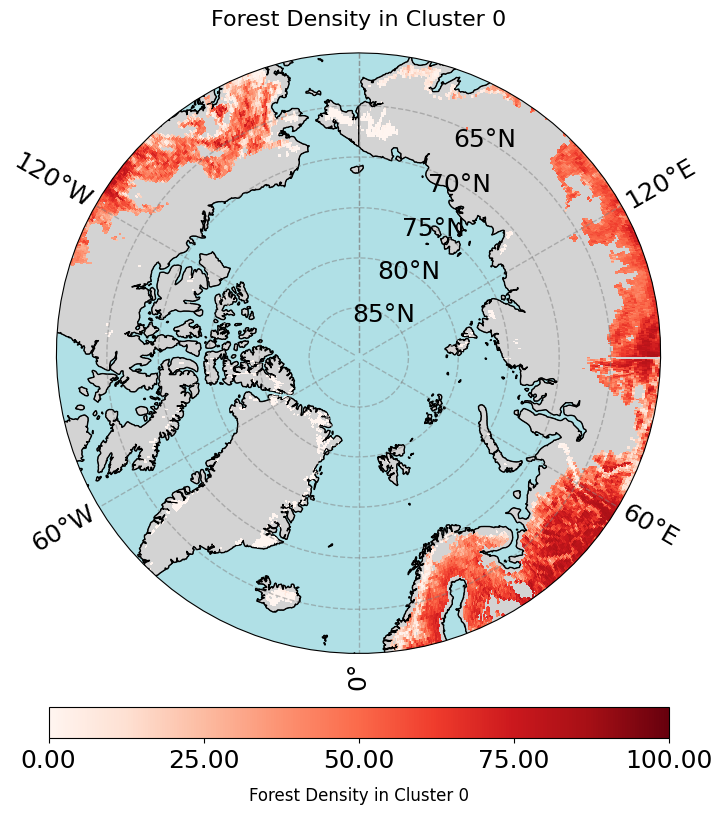

Mean Forest Density in Cluster 0:  44.12005


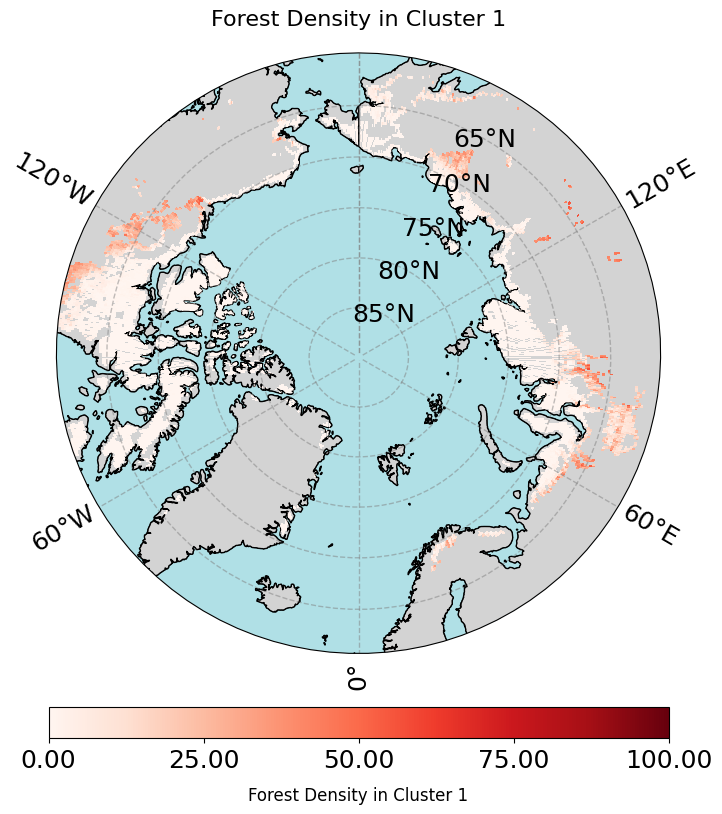

Mean Forest Density in Cluster 1:  4.500608


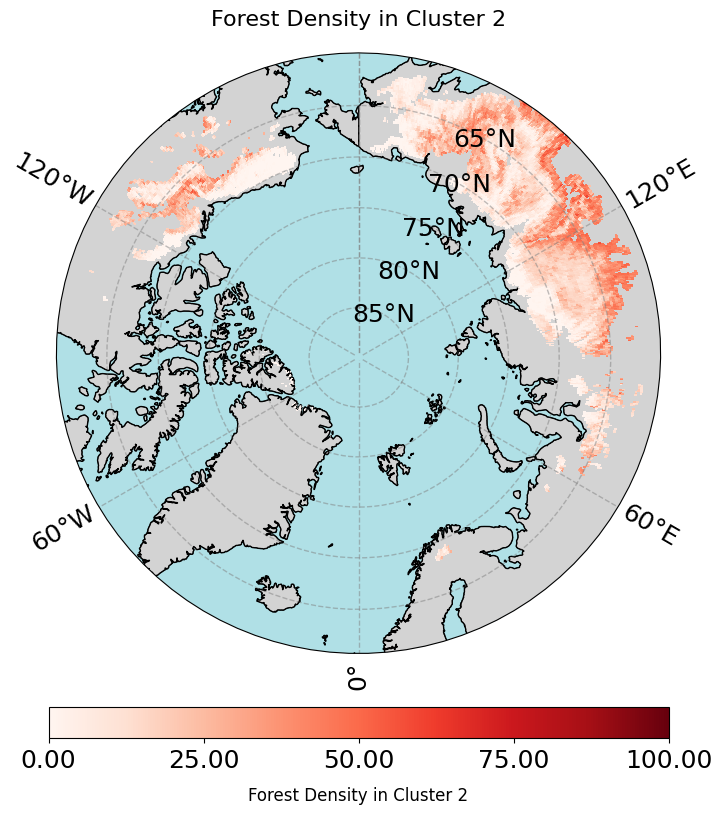

Mean Forest Density in Cluster 2:  16.370832


In [5]:
# Define the paths, and load the data
cluster_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc"
with nc.Dataset(cluster_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    TB_cluster = ds.variables['TB_cluster'][:] # (lat, lon)

Forest_density_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Forest_density/ForestDensity_1992_2020_60N.nc"
with nc.Dataset(Forest_density_path) as ds_forest:
    lat_vals = ds_forest.variables['lat'][:]
    lon_vals = ds_forest.variables['lon'][:]
    Forest_density = ds_forest.variables['forest_density'][:] # (time, lat, lon) = (29, 120, 1440) (time = 1992~2020)
    Forest_density_mean = ds_forest.variables['forest_density_mean'][:] # (lat, lon)

# Overlay the Forest density and TB cluster
Cluster0_forest_density = np.where(TB_cluster == 0, Forest_density_mean, np.nan)
Cluster1_forest_density = np.where(TB_cluster == 1, Forest_density_mean, np.nan)
Cluster2_forest_density = np.where(TB_cluster == 2, Forest_density_mean, np.nan)

# Plot the Forest density
for i in range(3):
    if i == 0:
        plot_Northpole(lon_vals, lat_vals, Cluster0_forest_density, "Forest Density in Cluster 0", "Reds", vmin=0, vmax=100, vcenter=50)
        print("Mean Forest Density in Cluster 0: ", np.nanmean(Cluster0_forest_density))
    elif i == 1:
        plot_Northpole(lon_vals, lat_vals, Cluster1_forest_density, "Forest Density in Cluster 1", "Reds", vmin=0, vmax=100, vcenter=50)
        print("Mean Forest Density in Cluster 1: ", np.nanmean(Cluster1_forest_density))
    elif i == 2:
        plot_Northpole(lon_vals, lat_vals, Cluster2_forest_density, "Forest Density in Cluster 2", "Reds", vmin=0, vmax=100, vcenter=50)
        print("Mean Forest Density in Cluster 2: ", np.nanmean(Cluster2_forest_density))
